<a href="https://colab.research.google.com/github/kagabrielco-netizen/LABORATORIOS-/blob/main/Laboratorio_UCV_MLP_Bank_Marketing_UCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3. Contexto del caso

Una entidad bancaria realiza campañas telefónicas para ofrecer depósitos a plazo. No todos los clientes aceptan la oferta. Por ello, el banco desea construir un modelo que permita priorizar a los clientes con mayor probabilidad de aceptar.

**Variable objetivo:**

- `y = yes`: el cliente aceptó el depósito.
- `y = no`: el cliente no aceptó el depósito.


## 4. Preparación del entorno

Ejecute esta celda si está trabajando en Google Colab o en un entorno local que aún no tiene las librerías instaladas.


In [1]:
%pip install ucimlrepo pandas scikit-learn matplotlib joblib -q

## 5. Importar librerías


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
import joblib


## 6. Cargar dataset real desde UCI

Se utilizará el dataset **Bank Marketing** de UCI Machine Learning Repository.


In [3]:
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets.squeeze()

print('Dimensión de X:', X.shape)
print('Dimensión de y:', y.shape)

X.head()

Dimensión de X: (45211, 16)
Dimensión de y: (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


## 7. Exploración inicial


In [4]:
df = X.copy()
df['target'] = y

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  target       45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df['target'].value_counts(normalize=True)

,proportion
target,
no,0.883015
yes,0.116985


### Interpretación

Observe si la variable objetivo está balanceada o desbalanceada. En problemas reales de negocio, muchas veces hay más clientes que dicen `no` que clientes que dicen `yes`.


## 8. Preparación de datos

El MLP necesita datos numéricos. Por ello:

- Las variables numéricas serán estandarizadas.
- Las variables categóricas serán transformadas con One-Hot Encoding.
- La variable objetivo será transformada a 0 y 1.


In [7]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('Variables numéricas:', numeric_features)
print('Variables categóricas:', categorical_features)

Variables numéricas: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [8]:
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print('Clases:', list(target_encoder.classes_))
print('Ejemplo y codificado:', y_encoded[:10])

Clases: ['no', 'yes']
Ejemplo y codificado: [0 0 0 0 0 0 0 0 0 0]


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

## 9. División entrenamiento / prueba

Se utilizará 70% para entrenamiento y 30% para prueba. El parámetro `stratify=y_encoded` mantiene la proporción de clases en ambos conjuntos.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (31647, 16)
Test: (13564, 16)


## 10. Entrenamiento del Perceptrón Multicapa

La arquitectura usada será:

- Primera capa oculta: 16 neuronas.
- Segunda capa oculta: 8 neuronas.
- Función de activación: ReLU.
- Optimizador: Adam.
- Early stopping: activado para reducir riesgo de overfitting.


In [11]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', mlp_model),
    ]
)

pipeline.fit(X_train, y_train)

print('Entrenamiento finalizado.')

Entrenamiento finalizado.


## 11. Evaluación del modelo


In [12]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

Accuracy : 0.9005
Precision: 0.6184
Recall   : 0.3900
F1-score : 0.4784


In [13]:
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

          no       0.92      0.97      0.94     11977
         yes       0.62      0.39      0.48      1587

    accuracy                           0.90     13564
   macro avg       0.77      0.68      0.71     13564
weighted avg       0.89      0.90      0.89     13564



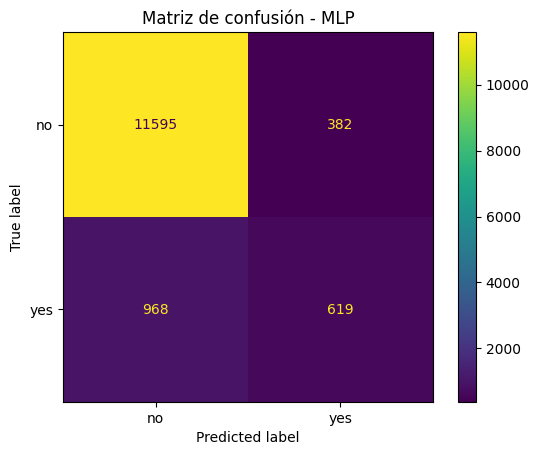

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_encoder.classes_,
)
plt.title('Matriz de confusión - MLP')
plt.show()

## 12. Curva de pérdida del entrenamiento

La pérdida muestra cómo el modelo fue aprendiendo durante las iteraciones.


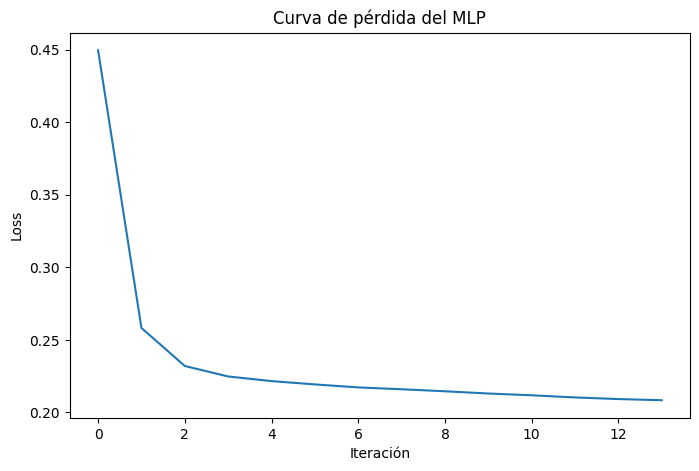

In [15]:
loss_curve = pipeline.named_steps['model'].loss_curve_

plt.figure(figsize=(8, 5))
plt.plot(loss_curve)
plt.xlabel('Iteración')
plt.ylabel('Loss')
plt.title('Curva de pérdida del MLP')
plt.show()

## 13. Comparación de arquitecturas

Ahora se entrenarán tres arquitecturas diferentes. El objetivo no es obtener el modelo perfecto, sino observar cómo cambia el rendimiento al modificar capas y neuronas.


In [16]:
architectures = [
    (8,),
    (16, 8),
    (32, 16, 8),
]

results = []

for architecture in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
    )

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model),
        ]
    )

    pipe.fit(X_train, y_train)
    predictions = pipe.predict(X_test)

    results.append(
        {
            'architecture': str(architecture),
            'accuracy': accuracy_score(y_test, predictions),
            'precision': precision_score(y_test, predictions),
            'recall': recall_score(y_test, predictions),
            'f1_score': f1_score(y_test, predictions),
            'iterations': pipe.named_steps['model'].n_iter_,
        }
    )

results_df = pd.DataFrame(results)
results_df

,architecture,accuracy,precision,recall,f1_score,iterations
0,"(8,)",0.902757,0.646608,0.372401,0.472611,16
1,"(16, 8)",0.900472,0.618382,0.390044,0.478362,14
2,"(32, 16, 8)",0.905264,0.625207,0.475110,0.539921,31


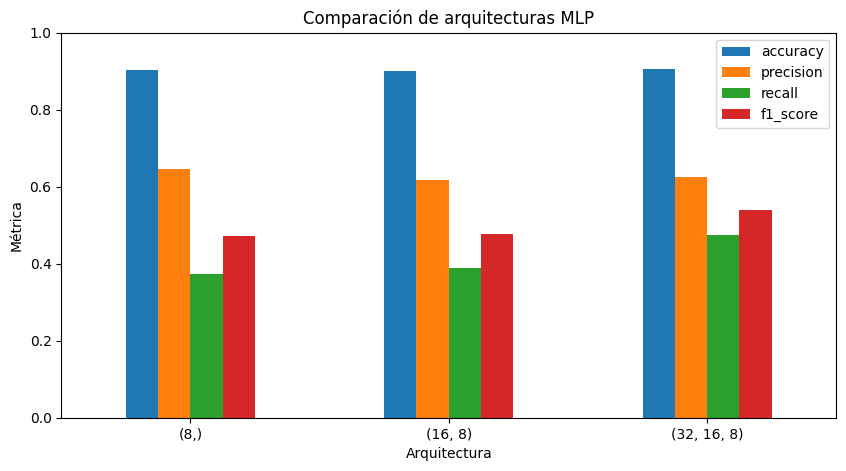

In [17]:
results_df.plot(
    x='architecture',
    y=['accuracy', 'precision', 'recall', 'f1_score'],
    kind='bar',
    figsize=(10, 5),
)
plt.title('Comparación de arquitecturas MLP')
plt.xlabel('Arquitectura')
plt.ylabel('Métrica')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 14. Guardar el modelo


In [18]:
joblib.dump(pipeline, 'mlp_bank_marketing_model.joblib')
print('Modelo guardado como mlp_bank_marketing_model.joblib')

Modelo guardado como mlp_bank_marketing_model.joblib


## 15. Preguntas de análisis


1. **¿Qué diferencia existe entre un perceptrón simple y un perceptrón multicapa?**
El perceptrón simple solo tiene una capa y separa datos linealmente. El multicapa agrega capas ocultas que le permiten aprender relaciones no lineales.

2. **¿Qué función cumplen las capas ocultas?**
Combinan y transforman las variables de entrada para detectar patrones complejos que una sola capa no podría identificar.

3. **¿Por qué fue necesario convertir variables categóricas a variables numéricas?**
Porque las redes neuronales solo procesan números, no texto (como "married" o "technician").

4. **¿Por qué se estandarizan las variables numéricas antes de entrenar una red neuronal?**
Para que todas las variables tengan una escala similar y ninguna domine el entrenamiento por tener valores más grandes (ej: balance vs edad).

5. **¿Qué significa `hidden_layer_sizes=(16, 8)`?**
Que el modelo tiene dos capas ocultas: la primera con 16 neuronas y la segunda con 8.

6. **¿Qué métrica considera más importante para este caso: accuracy, precision, recall o F1-score? Justifique.**
El recall, porque al banco le interesa identificar la mayor cantidad posible de clientes que sí aceptarían el depósito, aunque se generen algunos falsos positivos.

7. **¿Qué riesgos existen si el banco usa este modelo para tomar decisiones comerciales reales?**
Podría descartar clientes que sí estaban interesados (bajo recall) o generar campañas ineficientes por el desbalance de clases, afectando ingresos y la experiencia del cliente.

8. **¿Por qué un modelo más grande no siempre es mejor?**
Puede sobreajustarse (memorizar en vez de aprender), tardar más en entrenar y no necesariamente mejorar el rendimiento real con datos nuevos.